# Estudo IMDC — Replicação com as janelas dos Testes 1/2/3

Este estudo repete integralmente o benchmark clássico × quântico de dengue no Distrito Federal, porém usando **exatamente as janelas de validação do 2º Infodengue-Mosqlimate Dengue Challenge (IMDC)**, para permitir comparação direta com as 17 equipes que submeteram modelos para o DF.

**Janelas (cada uma é uma temporada de 52 semanas; treino expansivo desde jan/2022):**
- **T1** 2022-10-09 → 2023-10-01 (temporada típica)
- **T2** 2023-10-08 → 2024-09-29 (surto recorde de 2024)
- **T3** 2024-10-06 → 2025-09-28 (pós-surto)

Alvo: `casos_est` (InfoDengue). Métrica primária: WIS.

In [1]:
import matplotlib; matplotlib.use('Agg')
import os, sys, json, warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from IPython.display import Image, display
AQUI = os.path.abspath('..')
sys.path.insert(0, AQUI)
FIG = os.path.join(AQUI, 'figuras'); RES = os.path.join(AQUI, 'resultados')
import imdc_splits as S
ds = S.carregar_dataset(); CEN = S.montar_cenarios(ds)
print('features:', len(ds['feature_names']), '\n', ds['feature_names'])
rows=[]
for k,d in CEN.items():
    rows.append([k, S.DESCRICAO[k], len(d['y_train']), len(d['y_test']),
                 d['datas_test'][0], d['datas_test'][-1], int(d['y_test'].max())])
pd.DataFrame(rows, columns=['Cenário','Descrição','Treino (sem)','Teste (sem)','Início','Fim','Pico teste'])

features: 13 
 ['casos_est_lag1', 'casos_est_lag2', 'casos_est_lag3', 'casos_est_lag4', 'Rt_lag1', 'Rt_lag2', 'p_rt1_lag1', 'receptivo_lag1', 'transmissao_lag1', 'tempmed_lag1', 'umidmed_lag1', 'SE_sin', 'SE_cos']


,Cenário,Descrição,Treino (sem),Teste (sem),Início,Fim,Pico teste
0,T1,IMDC Teste 1 — temporada típica (out/2022 – o...,36,52,2022-10-09,2023-10-01,1562
1,T2,IMDC Teste 2 — surto recorde 2024 (out/2023 –...,88,52,2023-10-08,2024-09-29,25714
2,T3,IMDC Teste 3 — pós-surto (out/2024 – set/2025),140,52,2024-10-06,2025-09-28,947


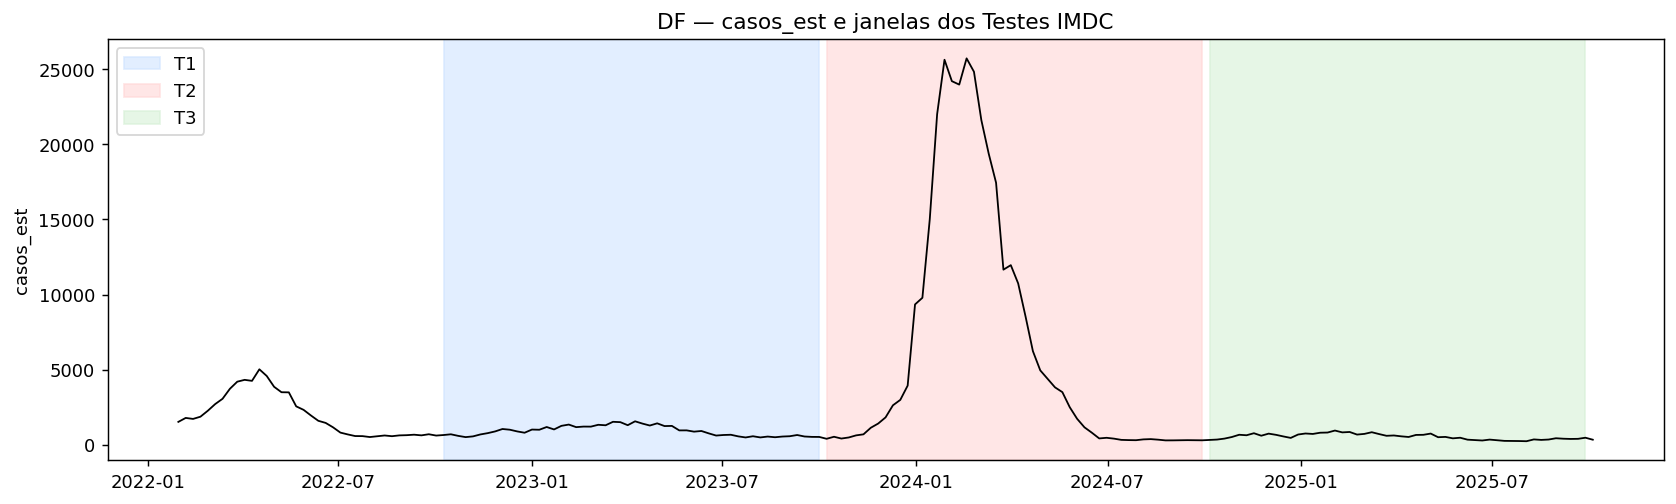

In [2]:
import matplotlib.pyplot as plt
datas = pd.to_datetime([str(x)[:10] for x in ds['datas']]); y = np.asarray(ds['y'])
fig, ax = plt.subplots(figsize=(13,4)); ax.plot(datas, y, 'k-', lw=1)
cores={'T1':'#cfe3ff','T2':'#ffd6d6','T3':'#d6f0d6'}
for k,(ini,fim) in S.JANELAS.items():
    ax.axvspan(pd.Timestamp(ini), pd.Timestamp(fim), color=cores[k], alpha=.6, label=k)
ax.set_title('DF — casos_est e janelas dos Testes IMDC'); ax.set_ylabel('casos_est'); ax.legend(); plt.tight_layout()
_p=os.path.join(FIG,'00_serie_janelas.png'); fig.savefig(_p, dpi=130, bbox_inches='tight'); plt.close(fig); display(Image(_p))